# Analise Exploratoria de Dados (EDA) - Base HR (FreeSQL)
**Projeto Avaliativo - Visualizacao de Dados e Business Intelligence [T3] - Modulo 1**

**Aluno:** Diogo Durval Koerich Pereira  |  **Turma:** T3

Este notebook importa os dois CSV extraidos das consultas SQL na base *Human Resources* (HR),
faz uma analise exploratoria simples, calcula as medidas estatisticas basicas dos salarios
(media, mediana, minimo e maximo) e gera os graficos de distribuicao.


In [1]:
# Configuracao e importacao das bibliotecas
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt

# Localiza a raiz do projeto (pasta que contem dados/query_01.csv),
# funcionando tanto a partir de python/ quanto da raiz do repositorio.
def achar_base():
    d = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(d, "dados", "query_01.csv")):
            return d
        d = os.path.dirname(d)
    return os.getcwd()

BASE_DIR = achar_base()
DADOS_DIR = os.path.join(BASE_DIR, "dados")
GRAF_DIR = os.path.join(BASE_DIR, "graficos")
os.makedirs(GRAF_DIR, exist_ok=True)

ACENTO, ACENTO2, ACENTO3 = "#3b6ea5", "#c44e52", "#55a868"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

def brl(x):
    return "US$ {:,.2f}".format(x)

print("Raiz do projeto:", BASE_DIR)


Raiz do projeto: /home/user/VISUALIZA-O-DE-DADOS-E-BUSINESS-INTELLIGENCE-T3-


## 1) Importacao dos arquivos CSV

In [2]:
df1 = pd.read_csv(os.path.join(DADOS_DIR, "query_01.csv"))  # Salario por Departamento e Cargo
df2 = pd.read_csv(os.path.join(DADOS_DIR, "query_02.csv"))  # Funcionarios por Regiao
print("query_01:", df1.shape, "| query_02:", df2.shape)
df1.head()


query_01: (106, 5) | query_02: (106, 8)


,EMPLOYEE_ID,EMPLOYEE_NAME,DEPARTMENT_NAME,JOB_TITLE,SALARY
0,205,Shelley Higgins,Accounting,Accounting Manager,12008
1,206,William Gietz,Accounting,Public Accountant,8300
2,200,Jennifer Whalen,Administration,Administration Assistant,4400
3,100,Steven King,Executive,President,24000
4,101,Neena Kochhar,Executive,Administration Vice President,17000


## 2) EDA - estrutura e qualidade dos dados

In [3]:
print("Tipos de dados (query_01):")
print(df1.dtypes, "\n")
print("Valores ausentes (query_01):")
print(df1.isna().sum(), "\n")
print("Valores ausentes (query_02):")
print(df2.isna().sum())


Tipos de dados (query_01):
EMPLOYEE_ID        int64
EMPLOYEE_NAME        str
DEPARTMENT_NAME      str
JOB_TITLE            str
SALARY             int64
dtype: object 

Valores ausentes (query_01):
EMPLOYEE_ID        0
EMPLOYEE_NAME      0
DEPARTMENT_NAME    0
JOB_TITLE          0
SALARY             0
dtype: int64 

Valores ausentes (query_02):
EMPLOYEE_ID        0
EMPLOYEE_NAME      0
DEPARTMENT_NAME    0
CITY               0
STATE_PROVINCE     1
COUNTRY_NAME       0
REGION_NAME        0
SALARY             0
dtype: int64


In [4]:
df2.head()

,EMPLOYEE_ID,EMPLOYEE_NAME,DEPARTMENT_NAME,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME,SALARY
0,201,Michael Hartstein,Marketing,Toronto,Ontario,Canada,Americas,13000
1,202,Pat Fay,Marketing,Toronto,Ontario,Canada,Americas,6000
2,100,Steven King,Executive,Seattle,Washington,United States of America,Americas,24000
3,101,Neena Kochhar,Executive,Seattle,Washington,United States of America,Americas,17000
4,102,Lex De Haan,Executive,Seattle,Washington,United States of America,Americas,17000


## 3) Medidas estatisticas basicas do salario
Media, mediana, minimo, maximo, desvio-padrao e quartis.

In [5]:
sal = df1["SALARY"]
resumo = {
    "funcionarios": int(sal.count()),
    "media": sal.mean(), "mediana": sal.median(),
    "minimo": sal.min(), "maximo": sal.max(),
    "desvio_padrao": sal.std(),
    "Q1": sal.quantile(0.25), "Q3": sal.quantile(0.75),
}
for k, v in resumo.items():
    print(f"{k:14}: {v:,.2f}" if isinstance(v, float) else f"{k:14}: {v}")

print("\nComparacao media x mediana:")
print("media  =", brl(sal.mean()))
print("mediana=", brl(sal.median()))
print("=> media > mediana: distribuicao assimetrica a direita (salarios altos da diretoria puxam a media).")
sal.describe()


funcionarios  : 106
media         : 6,456.75
mediana       : 6,150.00
minimo        : 2100
maximo        : 24000
desvio_padrao : 3,927.80
Q1            : 3,100.00
Q3            : 8,950.00

Comparacao media x mediana:
media  = US$ 6,456.75
mediana= US$ 6,150.00
=> media > mediana: distribuicao assimetrica a direita (salarios altos da diretoria puxam a media).


count      106.000000
mean      6456.754717
std       3927.798234
min       2100.000000
25%       3100.000000
50%       6150.000000
75%       8950.000000
max      24000.000000
Name: SALARY, dtype: float64

## 4) Comparacoes por departamento, cargo e regiao

In [6]:
por_depto = (df1.groupby("DEPARTMENT_NAME")["SALARY"]
             .agg(funcionarios="count", media="mean", mediana="median", minimo="min", maximo="max")
             .sort_values("media", ascending=False).round(2))
por_depto


,funcionarios,media,mediana,minimo,maximo
DEPARTMENT_NAME,,,,,
Executive,3,19333.33,17000.0,17000,24000
Accounting,2,10154.00,10154.0,8300,12008
Public Relations,1,10000.00,10000.0,10000,10000
Marketing,2,9500.00,9500.0,6000,13000
Sales,34,8955.88,8900.0,6100,14000
Finance,6,8601.33,8000.0,6900,12008
Human Resources,1,6500.00,6500.0,6500,6500
IT,5,5760.00,4800.0,4200,9000
Administration,1,4400.00,4400.0,4400,4400


In [7]:
por_cargo = (df1.groupby("JOB_TITLE")["SALARY"]
             .agg(funcionarios="count", media="mean").sort_values("media", ascending=False).round(2))
print("TOP 5 cargos por salario medio:")
display(por_cargo.head(5))
print("BOTTOM 5 cargos por salario medio:")
display(por_cargo.tail(5))


TOP 5 cargos por salario medio:


,funcionarios,media
JOB_TITLE,,
President,1,24000.0
Administration Vice President,2,17000.0
Marketing Manager,1,13000.0
Sales Manager,5,12200.0
Finance Manager,1,12008.0


BOTTOM 5 cargos por salario medio:


,funcionarios,media
JOB_TITLE,,
Programmer,5,5760.0
Administration Assistant,1,4400.0
Shipping Clerk,20,3215.0
Stock Clerk,20,2785.0
Purchasing Clerk,5,2780.0


In [8]:
por_regiao = (df2.groupby("REGION_NAME")["SALARY"]
              .agg(funcionarios="count", media="mean", mediana="median", minimo="min", maximo="max")
              .sort_values("funcionarios", ascending=False).round(2))
por_regiao


,funcionarios,media,mediana,minimo,maximo
REGION_NAME,,,,,
Americas,70,5191.66,3300.0,2100,24000
Europe,36,8916.67,8900.0,6100,14000


## 5) Graficos
Histograma (distribuicao geral), boxplots (por departamento e por regiao) e barras.

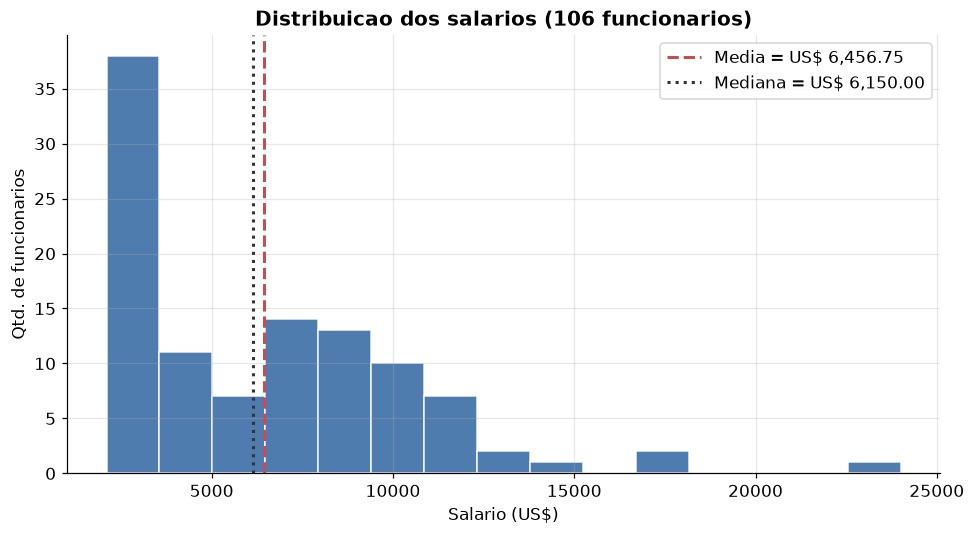

In [9]:
# 5.1 Histograma da distribuicao de salarios
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sal, bins=15, color=ACENTO, edgecolor="white", alpha=0.9)
ax.axvline(sal.mean(), color=ACENTO2, linestyle="--", linewidth=2, label="Media = "+brl(sal.mean()))
ax.axvline(sal.median(), color="#333333", linestyle=":", linewidth=2, label="Mediana = "+brl(sal.median()))
ax.set_title("Distribuicao dos salarios (106 funcionarios)", fontweight="bold")
ax.set_xlabel("Salario (US$)"); ax.set_ylabel("Qtd. de funcionarios"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(GRAF_DIR, "histograma_salarios.png")); plt.show()


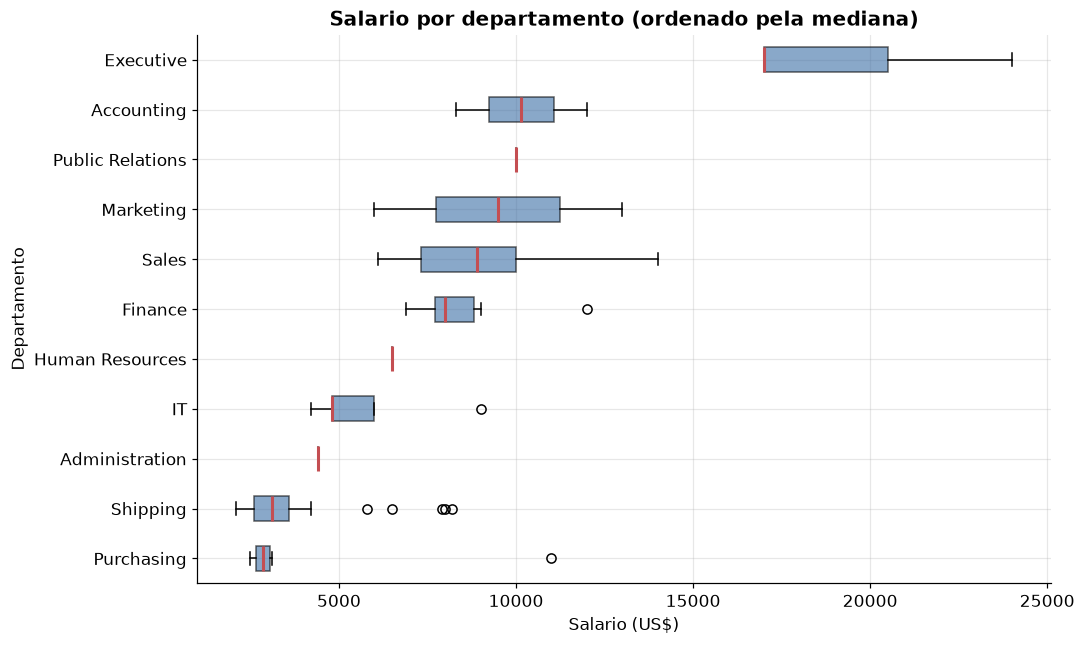

In [10]:
# 5.2 Boxplot de salario por departamento
ordem = df1.groupby("DEPARTMENT_NAME")["SALARY"].median().sort_values().index.tolist()
dados_box = [df1.loc[df1.DEPARTMENT_NAME == d, "SALARY"].values for d in ordem]
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(dados_box, orientation="horizontal", tick_labels=ordem, patch_artist=True,
                medianprops=dict(color=ACENTO2, linewidth=2))
for c in bp["boxes"]: c.set(facecolor=ACENTO, alpha=0.6)
ax.set_title("Salario por departamento (ordenado pela mediana)", fontweight="bold")
ax.set_xlabel("Salario (US$)"); ax.set_ylabel("Departamento")
fig.tight_layout(); fig.savefig(os.path.join(GRAF_DIR, "boxplot_salario_departamento.png")); plt.show()


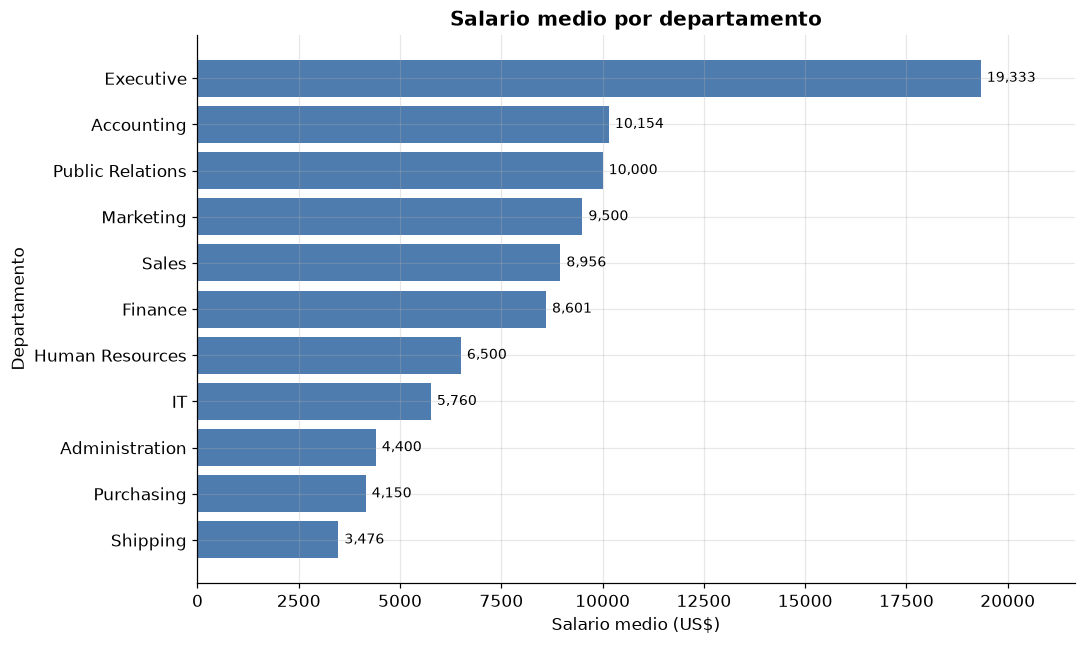

In [11]:
# 5.3 Barras - salario medio por departamento
media_dep = df1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.barh(media_dep.index, media_dep.values, color=ACENTO, alpha=0.9)
for b, v in zip(barras, media_dep.values):
    ax.text(v + 150, b.get_y()+b.get_height()/2, f"{v:,.0f}", va="center", fontsize=9)
ax.set_title("Salario medio por departamento", fontweight="bold")
ax.set_xlabel("Salario medio (US$)"); ax.set_ylabel("Departamento"); ax.margins(x=0.12)
fig.tight_layout(); fig.savefig(os.path.join(GRAF_DIR, "barras_media_salario_departamento.png")); plt.show()


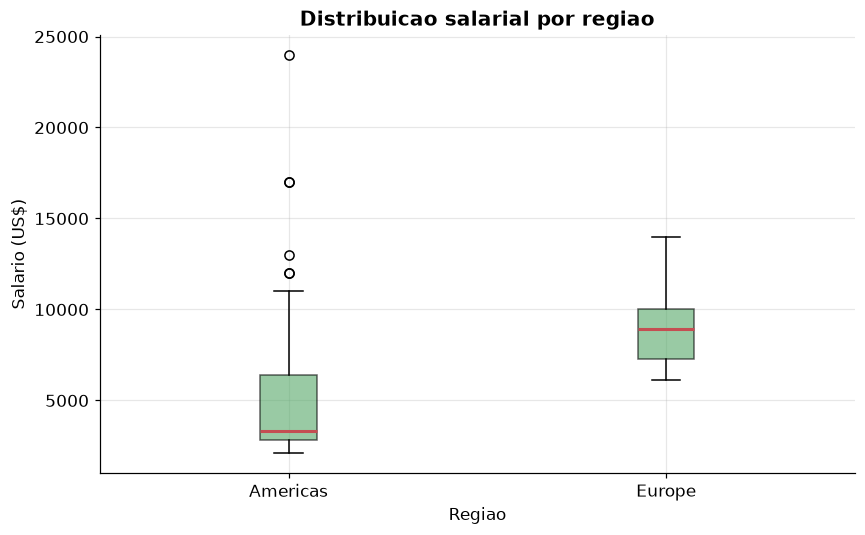

In [12]:
# 5.4 Boxplot de salario por regiao
ordem_reg = df2.groupby("REGION_NAME")["SALARY"].median().sort_values().index.tolist()
dados_reg = [df2.loc[df2.REGION_NAME == r, "SALARY"].values for r in ordem_reg]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(dados_reg, orientation="vertical", tick_labels=ordem_reg, patch_artist=True,
                medianprops=dict(color=ACENTO2, linewidth=2))
for c in bp["boxes"]: c.set(facecolor=ACENTO3, alpha=0.6)
ax.set_title("Distribuicao salarial por regiao", fontweight="bold")
ax.set_xlabel("Regiao"); ax.set_ylabel("Salario (US$)")
fig.tight_layout(); fig.savefig(os.path.join(GRAF_DIR, "boxplot_salario_regiao.png")); plt.show()


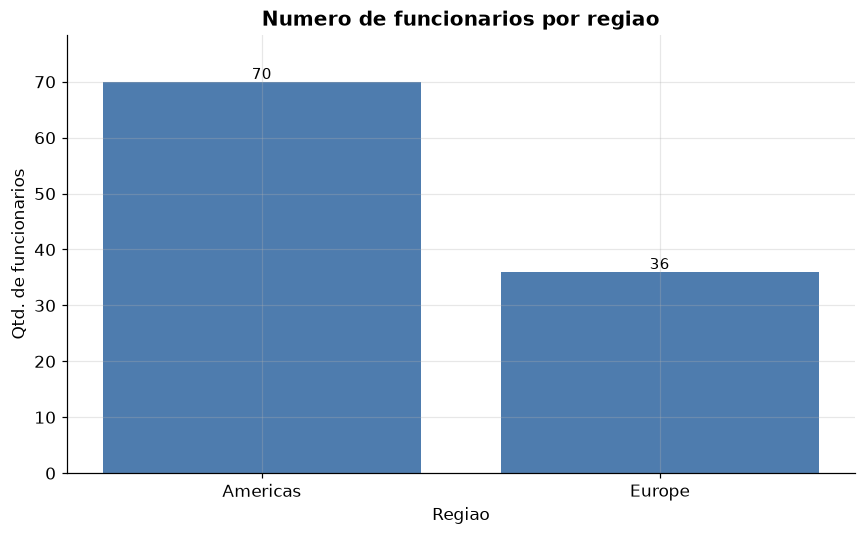

In [13]:
# 5.5 Barras - numero de funcionarios por regiao
cont_reg = df2["REGION_NAME"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(cont_reg.index, cont_reg.values, color=ACENTO, alpha=0.9)
for b, v in zip(barras, cont_reg.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, str(v), ha="center", fontsize=10)
ax.set_title("Numero de funcionarios por regiao", fontweight="bold")
ax.set_xlabel("Regiao"); ax.set_ylabel("Qtd. de funcionarios"); ax.margins(y=0.12)
fig.tight_layout(); fig.savefig(os.path.join(GRAF_DIR, "barras_funcionarios_regiao.png")); plt.show()


## 6) Conclusoes e insights
- **Assimetria:** a media dos salarios (~US$ 6.457) e maior que a mediana (~US$ 6.150), indicando
  distribuicao assimetrica a direita - poucos salarios muito altos (diretoria) puxam a media.
- **Departamentos:** *Executive* tem o maior salario medio (~US$ 19.333) e *Shipping* o menor (~US$ 3.476).
- **Regioes:** *Americas* concentra a maioria dos funcionarios (70), mas com mediana baixa (~US$ 3.300),
  por causa das areas operacionais (Shipping/Stock). *Europe* (36) tem mediana bem maior (~US$ 8.900),
  pois reune sobretudo Vendas e Relacoes Publicas.
- **Limitacao:** os dados nao trazem senioridade, jornada nem custo de vida por regiao - portanto as
  diferencas salariais nao devem, sozinhas, embasar decisoes de RH.
